# Handling Mixed Data

## What is mixed data?
Sometimes a col can have a mix of numerical and categorical values. This can be present as : 
1. Each value being a mix of numerical and categorical values.
    - ex : Train coach naming : A3, B8, etc 
    - Here A, B are the categorical data, describing the class of the coach 
    - and 3, 8 represent the coach number of that class and is the numerical value
2. Or some of the data values could be numeric while others categorical
    - ex : A, 8, 12, C, H, etc

In both cases, the col is split into two - one with the numerical data and the other with the categorical data.

### Implementation

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('datasets/titanic-mixed.csv')

In [3]:
df.sample(5)

,Cabin,Ticket,number,Survived
55,C52,19947,6,1
219,NaN,W/C 14208,4,0
767,NaN,364850,A,0
235,NaN,W./C. 6609,4,0
15,NaN,248706,3,1


#### Handling $2^{nd}$ type of mixed data

In [ ]:
df['number'].unique() # A for alone

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

In [12]:
#Extract numerical part
df['number_numerical'] = pd.to_numeric(df["number"], errors='coerce', downcast='integer')

In [13]:
# Extract categorical part
df['number_categorical'] = np.where(df['number_numerical'].isnull(), df['number'], np.nan)

In [14]:
df.head()

,Cabin,Ticket,number,Survived,extract_numeric,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,5.0,NaN
1,C85,PC 17599,3,1,3.0,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,6.0,NaN
3,C123,113803,3,1,3.0,3.0,NaN
4,NaN,373450,A,0,NaN,NaN,A


New cols created separating the numeric and categorical vals of number col

### Handling the $1^{st}$ type of mixed data 

In [15]:
# Unique values in cabin and ticket
df['Cabin'].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [16]:
df['Ticket'].unique()

<StringArray>
[       'A/5 21171',         'PC 17599', 'STON/O2. 3101282',
           '113803',           '373450',           '330877',
            '17463',           '349909',           '347742',
           '237736',
 ...
           '349212',           '349217',           '349257',
             '7552', 'C.A./SOTON 34068',  'SOTON/OQ 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 681, dtype: str

##### Too many unique values

In [22]:
# Extracting the numerical and categorical values from the Cabin col
df['cabin_num'] = df['Cabin'].str.extract('(\\d+)') # from each value of the cabin col, from each string extract the numeric value
df['cabin_cat'] = df['Cabin'].str[0] # extract the first letter of the string

In [23]:
df.head()

,Cabin,Ticket,number,Survived,extract_numeric,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,NaN,A,NaN,NaN


In [24]:
df['cabin_cat'].value_counts()

cabin_cat
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64

Now we have a limited number of categories of the cabins and just their counts instead of each cabin being a new category of it s own as before

<Axes: xlabel='cabin_cat'>

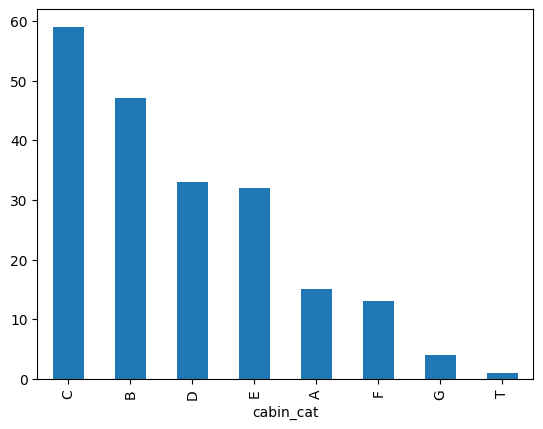

In [25]:
df['cabin_cat'].value_counts().plot(kind='bar')